In [1]:
import pandas as pd
import numpy as np

In [2]:
trans=pd.read_csv(r"C:\Gaurav Personal\DA & DS\Data Analyst Project\Enterprise Retail Customer Intelligence\Clean Data\clean_transaction_data.csv")
pdt=pd.read_csv(r"C:\Gaurav Personal\DA & DS\Data Analyst Project\Enterprise Retail Customer Intelligence\Clean Data\clean_product.csv")
hh=pd.read_csv(r"C:\Gaurav Personal\DA & DS\Data Analyst Project\Enterprise Retail Customer Intelligence\Clean Data\clean_hh_demographic.csv")

In [52]:
#1. Dataset Overview
print(trans.shape)
print(pdt.shape)
print(hh.shape)

(2595732, 12)
(92353, 7)
(801, 8)


In [5]:
print(trans.size)
print(pdt.size)
print(hh.size)

31148784
646471
6408


In [6]:
trans.head()

,household_key,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE,STORE_ID,RETAIL_DISC,TRANS_TIME,WEEK_NO,COUPON_DISC,COUPON_MATCH_DISC
0,2375,26984851472,1,1004906,1,1.39,364,-0.60,1631,1,0.0,0.0
1,2375,26984851472,1,1033142,1,0.82,364,0.00,1631,1,0.0,0.0
2,2375,26984851472,1,1036325,1,0.99,364,-0.30,1631,1,0.0,0.0
3,2375,26984851472,1,1082185,1,1.21,364,0.00,1631,1,0.0,0.0
4,2375,26984851472,1,8160430,1,1.50,364,-0.39,1631,1,0.0,0.0


In [7]:
trans.tail()

,household_key,BASKET_ID,DAY,PRODUCT_ID,QUANTITY,SALES_VALUE,STORE_ID,RETAIL_DISC,TRANS_TIME,WEEK_NO,COUPON_DISC,COUPON_MATCH_DISC
2595727,1598,42305362535,711,92130,1,0.99,3228,0.00,1520,102,0.0,0.0
2595728,1598,42305362535,711,114102,1,8.89,3228,0.00,1520,102,0.0,0.0
2595729,1598,42305362535,711,133449,1,6.99,3228,0.00,1520,102,0.0,0.0
2595730,1598,42305362535,711,6923644,1,4.50,3228,-0.49,1520,102,0.0,0.0
2595731,1598,42305362535,711,14055192,1,6.99,3228,0.00,1520,102,0.0,0.0


In [8]:
pdt.head()

,PRODUCT_ID,MANUFACTURER,DEPARTMENT,BRAND,COMMODITY_DESC,SUB_COMMODITY_DESC,CURR_SIZE_OF_PRODUCT
0,25671,2,GROCERY,National,FRZN ICE,ICE - CRUSHED/CUBED,22 LB
1,26081,2,MISC. TRANS.,National,NO COMMODITY DESCRIPTION,NO SUBCOMMODITY DESCRIPTION,
2,26093,69,PASTRY,Private,BREAD,BREAD:ITALIAN/FRENCH,
3,26190,69,GROCERY,Private,FRUIT - SHELF STABLE,APPLE SAUCE,50 OZ
4,26355,69,GROCERY,Private,COOKIES/CONES,SPECIALTY COOKIES,14 OZ


In [9]:
pdt.tail()

,PRODUCT_ID,MANUFACTURER,DEPARTMENT,BRAND,COMMODITY_DESC,SUB_COMMODITY_DESC,CURR_SIZE_OF_PRODUCT
92348,18293142,6384,DRUG GM,National,BOOKSTORE,PAPERBACK BOOKS,
92349,18293439,6393,DRUG GM,National,BOOKSTORE,CHILDRENS LOW END,
92350,18293696,6406,DRUG GM,National,BOOKSTORE,PAPERBACK BEST SELLER,
92351,18294080,6442,DRUG GM,National,BOOKSTORE,PAPERBACK BOOKS,
92352,18316298,764,GROCERY,National,PAPER TOWELS,PAPER TOWELS & HOLDERS,


In [10]:
hh.head()

,classification_1,classification_2,classification_3,HOMEOWNER_DESC,classification_5,classification_4,KID_CATEGORY_DESC,household_key
0,Age Group6,X,Level4,Homeowner,Group5,2,None/Unknown,1
1,Age Group4,X,Level5,Homeowner,Group5,2,None/Unknown,7
2,Age Group2,Y,Level3,Unknown,Group4,3,1,8
3,Age Group2,Y,Level6,Homeowner,Group4,4,2,13
4,Age Group4,Z,Level5,Homeowner,Group3,1,None/Unknown,16


In [11]:
hh.tail()

,classification_1,classification_2,classification_3,HOMEOWNER_DESC,classification_5,classification_4,KID_CATEGORY_DESC,household_key
796,Age Group3,Y,Level5,Homeowner,Group5,2,None/Unknown,2494
797,Age Group4,X,Level6,Homeowner,Group6,3,1,2496
798,Age Group4,Y,Level4,Unknown,Group2,1,None/Unknown,2497
799,Age Group2,Y,Level5,Homeowner,Group5,2,None/Unknown,2498
800,Age Group2,Y,Level1,Unknown,Group4,3,1,2499


In [21]:
#2. Executive KPIs
total_revenue = trans["SALES_VALUE"].sum()
total_transactions = trans["BASKET_ID"].nunique()
total_customers = trans["household_key"].nunique()
total_products = pdt["PRODUCT_ID"].nunique()
total_stores = trans["STORE_ID"].nunique()
total_items_sold = trans["QUANTITY"].sum()

print("total_revenue =" ,total_revenue)
print("total_transactions =",total_transactions)
print("total_customers =",total_customers)
print("total_products =",total_products)
print("total_stores =",total_stores)
print("total_items_sold =",total_items_sold)

#Gives management a quick overview of the business.

total_revenue = 8057463.08
total_transactions = 276484
total_customers = 2500
total_products = 92353
total_stores = 582
total_items_sold = 260685622


In [22]:
#3. Revenue Distribution
trans["SALES_VALUE"].describe()

count    2.595732e+06
mean     3.104120e+00
std      4.182274e+00
min      0.000000e+00
25%      1.290000e+00
50%      2.000000e+00
75%      3.490000e+00
max      8.400000e+02
Name: SALES_VALUE, dtype: float64

<Axes: >

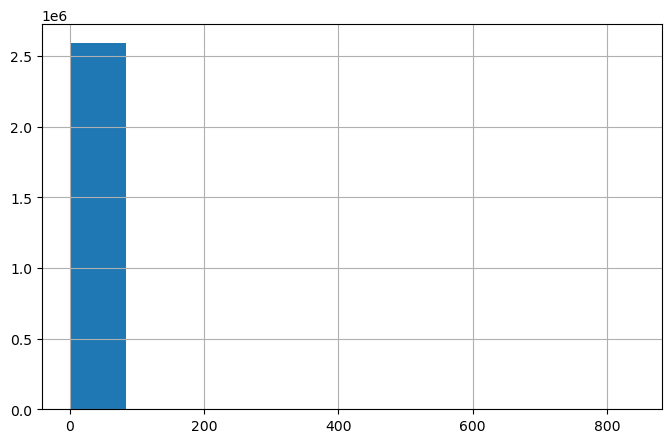

In [23]:
trans["SALES_VALUE"].hist(figsize=(8,5))

In [30]:
#4. Weekly Sales Trend
weekly_sales = trans.groupby("WEEK_NO")["SALES_VALUE"].sum()
print(weekly_sales)
#Identify peak and low sales weeks

WEEK_NO
1        5211.16
2       10821.35
3       13498.20
4       15965.99
5       20139.82
         ...    
98      98949.62
99     101363.92
100     93063.10
101     84407.25
102     71968.63
Name: SALES_VALUE, Length: 102, dtype: float64


In [32]:
#5. Top 10 Stores
trans.groupby("STORE_ID")["SALES_VALUE"].sum().nlargest(10)

STORE_ID
367      267614.34
406      216781.77
361      144698.85
429      142391.01
343      140455.75
356      137588.68
381      132488.15
375      130396.51
292      130005.18
31782    121726.54
Name: SALES_VALUE, dtype: float64

In [34]:
#6. Top Departments
sales_department = (trans.merge(pdt,on="PRODUCT_ID").groupby("DEPARTMENT")["SALES_VALUE"].sum().sort_values(ascending=False))
print(sales_department)

DEPARTMENT
GROCERY            4093814.14
DRUG GM            1055358.03
PRODUCE             557452.11
MEAT                548786.81
KIOSK-GAS           544222.28
MEAT-PCKGD          412436.77
DELI                260866.51
PASTRY              121739.86
MISC SALES TRAN     119960.04
NUTRITION            97669.04
SEAFOOD-PCKGD        63093.62
FLORAL               39653.34
COSMETICS            32360.37
SALAD BAR            30953.30
SEAFOOD              29496.92
SPIRITS              21670.88
MISC. TRANS.         10678.69
GARDEN CENTER         7667.82
TRAVEL & LEISUR       2550.38
CHEF SHOPPE           2290.80
RESTAURANT            1986.76
COUP/STR & MFG        1027.72
FROZEN GROCERY         653.26
AUTOMOTIVE             452.66
RX                     159.56
GM MERCH EXP           101.10
DAIRY DELI              73.23
CNTRL/STORE SUP         49.05
PHOTO                   41.40
DELI/SNACK BAR          36.08
VIDEO                   34.77
POSTAL CENTER           24.01
VIDEO RENTAL            21.46

In [36]:
#7. Brand Analysis
trans.merge(pdt,on="PRODUCT_ID").groupby("BRAND")["SALES_VALUE"].sum()

BRAND
National    5820201.75
Private     2237261.33
Name: SALES_VALUE, dtype: float64

In [41]:
#8. Customer Purchase Distribution
customer_sales = trans.groupby("household_key")["SALES_VALUE"].sum()
print(customer_sales)

household_key
1       4330.16
2       1954.34
3       2653.21
4       1200.11
5        779.06
         ...   
2496    4339.66
2497    7111.98
2498    2601.60
2499    3394.07
2500    5486.16
Name: SALES_VALUE, Length: 2500, dtype: float64


In [51]:
#9. Discount Analysis
discount = {"Retail Discount":abs(trans["RETAIL_DISC"].sum()),"Coupon Discount":abs(trans["COUPON_DISC"].sum())}
print(discount)

{'Retail Discount': np.float64(1398334.84), 'Coupon Discount': np.float64(42611.53999999999)}


In [49]:
#10. Correlation
trans[["SALES_VALUE","QUANTITY","RETAIL_DISC","COUPON_DISC"]].corr()

,SALES_VALUE,QUANTITY,RETAIL_DISC,COUPON_DISC
SALES_VALUE,1.000000,0.587993,-0.250082,-0.037573
QUANTITY,0.587993,1.000000,-0.039065,0.006505
RETAIL_DISC,-0.250082,-0.039065,1.000000,0.045557
COUPON_DISC,-0.037573,0.006505,0.045557,1.000000
